# Modularity Maximization & Pruning Thesis Experimentation (Cleaned Code)
#### Abby Headstrom
#### Dartmouth College Undergraduate Thesis 2026

This work was originally based off experimentation in the origial HyperModularity repository. Specifically, it was based off of the alternating AON notebook in the "demos" folder, which mimics the methods described in the original paper. 

In [2]:
# Import the necessary packages
using Revise

# Activate the project environment 
# Note: adjust the (" ") based on where the file is in the filetree
using Pkg; Pkg.activate("../.") 
using HyperModularity
#Pkg.add(["DataFrames", "CSV", "Plots"])

# Used all of these at some point - potentially can cut some of them...
using CSV
using DataFrames
using Graphs
using SparseArrays
using LinearAlgebra
using Printf
using Plots   # needed for β/γ trajectory plots and λ sweep summary

  Activating project at `~/Documents/ALL - Research copy/Code/hyper_mod_paper/HyperModularity.jl`
[ Info: Precompiling HyperModularity [bc4352e7-2825-48c1-aa5c-95462f20dcc0] (cache misses: wrong source (6))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## Select the dataset and set variables 

In my thesis I stuck to a constant maximum edge size of 5. In future work this could be adjuststed.

Note - on some datasets I was getting errors when trying to read the labels, so I set them to false. Some functions in the original repository require a "true" Z (label) vector, so I set a "false" label vector with all "0" group assignments for each node. Future work looking at the accuracy of these clustering assigments compared to the preset labels could address this and change the false_Z labeling. 

In [4]:
dataset = "contact-primary-school-classes"
maxsize = 5   # maximum hyperedge size to consider
minsize = 2    # minimum hyperedge size to consider
return_labels = false
H = read_hypergraph_data(dataset, maxsize, minsize, return_labels)

num_nodes = length(H.N)
false_Z = zeros(Int64, num_nodes)


# Store the hypergraph as an edgelist + weights vector (convenient for some operations)
EdgeList, weights = HyperModularity.hyperedge_formatting(H);

### FUNCTION: Largest Connected Component
NOTE: this could definitely be added to a julia script for more clean code 

I added this function to take a given hypergraph and find/return just it's largest connected component. This is important because we prune the hypergraph (see above) to only have edges of a maximum edge size, so after this pruning the HG could become disconnected. This code addresses that issue. 

In [4]:
function largest_connected_component(H::hypergraph)
    n = length(H.N)

    # ── Union-Find: find root of x with path compression ────────────
    parent = collect(1:n)
    rank   = zeros(Int, n)

    function find(x)
        while parent[x] != x
            parent[x] = parent[parent[x]]   # path compression
            x = parent[x]
        end
        return x
    end

    # ── Union-Find: merge components containing x and y ──────────────
    function union!(x, y)
        rx, ry = find(x), find(y)
        rx == ry && return
        if rank[rx] < rank[ry]; rx, ry = ry, rx; end
        parent[ry] = rx
        if rank[rx] == rank[ry]; rank[rx] += 1; end
    end

    # Connect all nodes that share a hyperedge
    for (sz, edges) in H.E
        for (edge, _) in edges
            for i in 2:length(edge)
                union!(edge[1], edge[i])
            end
        end
    end

    # ── Identify the largest component ───────────────────────────────
    comp_sizes = Dict{Int, Int}()
    for node in H.N
        root = find(node)
        comp_sizes[root] = get(comp_sizes, root, 0) + 1
    end
    lcc_root  = argmax(comp_sizes)
    lcc_nodes = Set(node for node in H.N if find(node) == lcc_root)

    # ── Remap node IDs to be contiguous (1:n_lcc) ───────────────────
    sorted_nodes = sort(collect(lcc_nodes))
    node_map     = Dict(old => new for (new, old) in enumerate(sorted_nodes))
    n_lcc        = length(sorted_nodes)

    # ── Keep only edges where ALL nodes are in the LCC ──────────────
    E_lcc = Dict{Integer, Dict}()
    for (sz, edges) in H.E
        for (edge, _) in edges
            all(v -> v in lcc_nodes, edge) || continue
            new_edge = sort([node_map[v] for v in edge])
            if !haskey(E_lcc, sz)
                E_lcc[sz] = Dict()
            end
            E_lcc[sz][new_edge] = 1
        end
    end

    # Fill in missing size keys (required by hypergraph struct)
    if !isempty(E_lcc)
        for k in 1:maximum(keys(E_lcc))
            if !haskey(E_lcc, k); E_lcc[k] = Dict(); end
        end
    end

    nodes_in_edges  = Set(v for (sz, edges) in E_lcc for (edge, _) in edges for v in edge)
    isolated_in_lcc = setdiff(Set(values(node_map)), nodes_in_edges)
    println("LCC nodes with no edges after filtering: $isolated_in_lcc")

    # ── Recompute degree vector for LCC nodes ────────────────────────
    D_lcc = zeros(Int64, n_lcc)
    for (sz, edges) in E_lcc
        for (edge, _) in edges
            D_lcc[edge] .+= 1
        end
    end

    N_lcc = 1:n_lcc
    return hypergraph(N_lcc, E_lcc, D_lcc), sorted_nodes
end

largest_connected_component (generic function with 1 method)

### FUNCTION: reorder partition labels

This function assigns a cannonical labeling to the paritition vector

In [5]:
function reorder_Z(Z, k)

    # Set the old and new partition map 
    z_map     = zeros(k)               # map: old label → new label
    Z_new     = Vector{Int}(undef, length(Z))   # new labels

    # keep track of the next available label
    max_clust = 1                     

    # For each node, either assign it to its new group label or start a new lable #
    for i in 1:length(Z)
        n = Z[i]
        if z_map[n] == 0               # first time seeing this label
            z_map[n]  = max_clust
            max_clust += 1
        end
        Z_new[i] = z_map[n]
    end
    return Z_new
end

reorder_Z (generic function with 1 method)

In [7]:
H_lcc, original_nodes = largest_connected_component(H)

LCC nodes with no edges after filtering: Set{Int64}()


(hypergraph
  N: Array{Int64}((242,)) [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  233, 234, 235, 236, 237, 238, 239, 240, 241, 242]
  E: Dict{Int64, Dict}
  D: Array{Int64}((242,)) [236, 150, 183, 105, 147, 74, 49, 159, 222, 244  …  48, 141, 72, 114, 34, 34, 37, 84, 36, 102]
, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  233, 234, 235, 236, 237, 238, 239, 240, 241, 242])

In [11]:
# Build the alternative hypergraph storage format used by AON_Louvain and learn_omega_aon
d, n, kmax, e2n, n2e, weights, edge_lengths = HyperModularity.alternate_hypergraph_storage(H_lcc);

### FUNCTION: AON_alternating 
This is the main function for the code. 


In [ ]:
function run_aon_alternating(
        H_lcc, e2n, n2e, weights, d, n, kmax, edge_lengths;
        max_iters        = 10000,
        randflag         = true,
        verbose          = false,
        maxits           = 100,
        print_output     = false
    )

    # ── Initialize partition and parameters ──────────────────────────
    Z           = CliqueExpansionModularity(H_lcc)
    β, γ, omega = learn_omega_aon(e2n, weights, Z, kmax, d, n)

    # ── Storage ──────────────────────────────────────────────────────
    unique_ptns  = Vector{Int}[]
    past_results = Dict{Int, Tuple{Float64, Vector{Int}, Vector{Float64}, Vector{Float64}}}()

    # beta_history[i, k] = β_k used in iteration i  (pre-allocated, trimmed at end)
    # gamma_history[i, k] = γ_k used in iteration i
    beta_history  = zeros(Float64, max_iters, kmax)
    gamma_history = zeros(Float64, max_iters, kmax)
    all_z_history = Vector{Int}[]


    println("Starting alternating AON optimization...")
    println("Initial β = $β")
    println("Initial γ = $γ")




    # loop through the set number of iterations
    for i in 1:max_iters
        if print_output
            println("── Iteration $i ──────────────────────────────")
        end

        # Record β and γ BEFORE the Louvain step — these are the parameters
        # that drive partition search in this iteration
        beta_history[i, :]  = β
        gamma_history[i, :] = γ

        # FINDING THe PARTITION
        # Run the AON algorithm from the original code. This gives back all partitions found in the search
        AllClusterings = AON_Louvain(
            n2e, e2n, weights, d, edge_lengths, β, γ, kmax,
            randflag, maxits, verbose)
        
        # Take only the final partition found in the search (standard in the louvain search)
        Z = AllClusterings[:, end]

        # reorder Z so that the labes are cannonical and add to the partition history
        Z = reorder_Z(Z, length(unique(Z)))
        push!(all_z_history, Z)
        nk = length(unique(Z))

        # Track whether this partition has been seen before
        if Z in unique_ptns
            if print_output
                println("  [FLAG] Partition already seen before")
            end
        else
            push!(unique_ptns, Z)
        end
        

        # Evaluate modularity under the current omega (from previous iteration)
        # This is equivalent to the algorithm in the thesis, which evaluates the modularity score for the current partition under the parameter estimates that were used to find it
        modu, likeli = modularity_aon(H_lcc, Z, omega; likelihood=true)
        past_results[i] = (modu, copy(Z), copy(β), copy(γ))

        # ── SECOND CHECK ─────────────────────────────────────────────
        # As a note, this step is routinely called "second check" because it was initially implemented as a second check to loop throuh the other iterations
        # for ease, it is kept as "second check," even though it is just the check step in the algorithm

        # Re-score ALL previously seen unique partitions under the current omega 
        # This is the key change from the original code, looking if there were any prior partitions found that were better than the one we just found
        # The naming conventions here use "second" to follow the second check title
        second_best_modu = modu
        second_best_Z    = Z
        second_best_idx  = -1


        # NOTE: A BIG area for improvement could be to reduce the number of times modularity is computed here 
        # In every iteration we are re-computing the modularity score for almost all of the previous partitions. Thus, it could be much more efficient to store the scores 
        # throughout all of the iterations. 
        # This also could be adjusted to only run when there is a unique partition found rather than every time. 
        for (j, past_Z) in enumerate(unique_ptns)
            past_modu = modularity_aon(H_lcc, past_Z, omega; likelihood=false)
            if past_modu > second_best_modu
                second_best_modu = past_modu
                second_best_Z    = past_Z
                second_best_idx  = j
            end
        end

        # update Z to be the best partition found (if different than the original one)
        if second_best_idx != -1
            Z               = second_best_Z   # next iteration starts from the winner
        end


        # Now reevaluate the parameters under the new partition (selected after the check phase)
        # Again, this could be made more efficient by saving prior values and using a lookup table
        
        # skip the re-estimation if Z is length one
        # This was addded to avoid edge cases where the partition is just one cluster
        if length(unique(Z)) == 1
            println("Single cluster partition — skipping parameter update")
        else
            β, γ, omega = learn_omega_aon(e2n, weights, Z, kmax, d, n)
            modu, likeli = modularity_aon(H_lcc, Z, omega; likelihood=true)
        end



        # NOTE: this was a debugging check when investigating the beta and gamma vlalues

        # for k = 2:kmax
        #     β[k] = log(omega[1,k]) - log(omega[2,k])
        #     γ[k] = (omega[1,k] - omega[2,k]) / β[k]
        #     println("k=$k: ω₁=$(omega[1,k])  ω₀=$(omega[2,k])  β=$(β[k])  γ=$(γ[k])")
        # end

        

        # # print every 5,000 iterations 
        # if i % 1000 == 0
        #     println("on iteration $(i)")
        # end
    end


    println("\n─── Alternating optimization complete ───")
    println("Unique partitions found : $(length(unique_ptns))")
    println("Best modularity         : $best_modularity")
    println("Best β                  : $best_beta")
    println("Best γ                  : $best_gamma")

    return (
        unique_ptns   = unique_ptns,
        past_results  = past_results,
        beta_history  = beta_history,
        gamma_history = gamma_history,
        n_iters       = actual_iters,
        all_z_history = all_z_history
    )
end

run_aon_alternating (generic function with 1 method)

### Run the AON alternating funtion 

In [ ]:
results = run_aon_alternating(
    H_lcc, e2n, n2e, weights, d, n, kmax, edge_lengths;
    max_iters        = 10000,
    randflag         = true,
    verbose          = false,
    maxits           = 100,
)


unique_ptns   = results.unique_ptns
past_results  = results.past_results
beta_history  = results.beta_history
gamma_history = results.gamma_history
n_iters       = results.n_iters
all_z_history = results.all_z_history

### Function: plot the parameter history from the AON run

In [ ]:

# history: Matrix of shape (n_iters × kmax)
# Each column k gives the value of the parameter for edge size k over all iterations
function plot_param_history(history, param_name, kmax, n_iters)
    iters = 1:n_iters
    p = plot(
        layout       = (kmax-1, 1),
        size         = (700, 200 * kmax),
        left_margin  = 40Plots.px,
        bottom_margin = 20Plots.px
    )
    for k in 2:kmax
        plot!(
            p, iters, history[:, k];
            subplot   = k-1,
            label     = "$(param_name)_$(k)  (edge size k=$k)",
            xlabel    = k == kmax ? "Iteration" : "",
            ylabel    = "$(param_name)_$(k)",
            title     = "Edge size k=$k",
            linewidth = 2,
            legend    = :topright,
            color     = k
        )
    end
    return p
end

plot_param_history (generic function with 1 method)

## Plot beta and gamma histories for each edge size

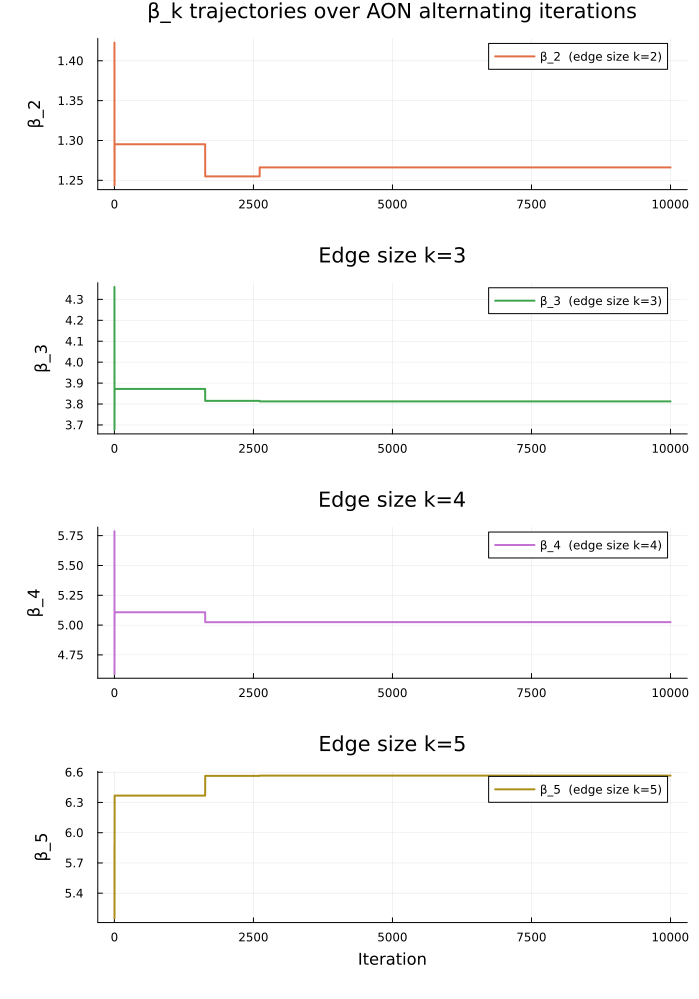

In [ ]:
# Plot β_k trajectories — one subplot per edge size k
Plots.closeall()
p_beta = plot_param_history(beta_history, "β", kmax, n_iters)
title!(p_beta, "β_k trajectories over AON alternating iterations", subplot=1)
savefig(p_beta, "beta_trajectories_school.pdf")
display(p_beta)

In [ ]:
# Plot γ_k trajectories — one subplot per edge size k
p_gamma = plot_param_history(gamma_history, "γ", kmax, n_iters)
title!(p_gamma, "γ_k trajectories over AON alternating iterations", subplot=1)
savefig(p_gamma, "gamma_trajectories_school.pdf")
display(p_gamma)

### Plot: cluster-count history 
Plotting the number of communities found in each iteration of the alternating AON run

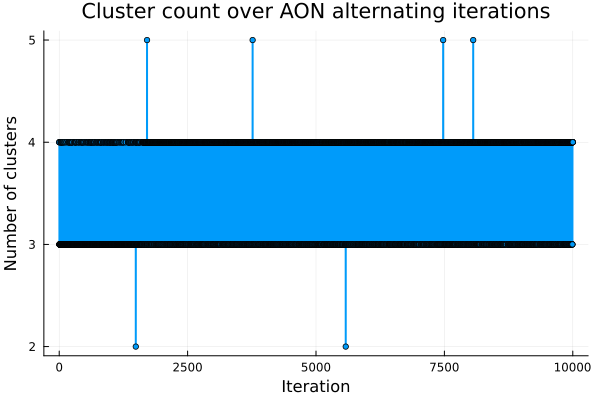

In [ ]:

cluster_counts_history = [length(unique(all_z_history[i])) for i in 1:length(all_z_history)]

Plots.closeall()
p_clusters = plot(
    1:n_iters, cluster_counts_history;
    xlabel     = "Iteration",
    ylabel     = "Number of clusters",
    title      = "Cluster count over AON alternating iterations",
    linewidth  = 2,
    marker     = :circle,
    markersize = 3,
    legend     = false
)
savefig(p_clusters, "cluster_counts_school.pdf")
display(p_clusters)

### Plot: NMI over paritions 
For each iteration, plot the NMB between the current partition and the one that was found right before it. A consistent line of NMI =1 means that the same partition is consistenly being found in a row, and if it bounces around it can help tell us that there is still a lot of movement among the partitions. 

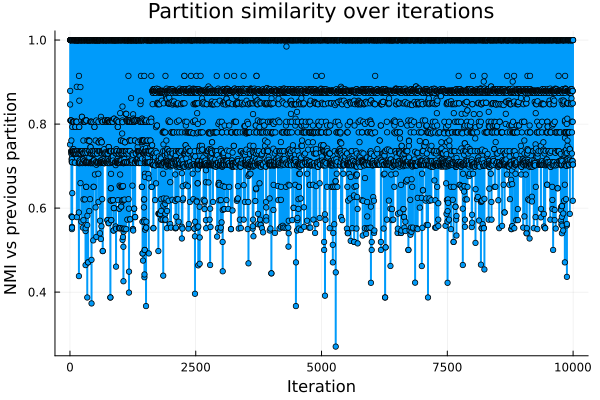

In [ ]:
# Compute NMI between consecutive partitions
nmi_consecutive = [
    mutualInformation(all_z_history[i-1], all_z_history[i], true)
    for i in 2:length(all_z_history)
]

p_nmi = plot(
    2:length(all_z_history), nmi_consecutive;
    xlabel     = "Iteration",
    ylabel     = "NMI vs previous partition",
    title      = "Partition similarity over iterations",
    linewidth  = 2,
    marker     = :circle,
    markersize = 3,
    legend     = false
)
savefig(p_nmi, "consecutive_nmi_school.pdf")
display(p_nmi)

### Plot: tracking the number of unique partitions found vs number of iterations
This block of code aims to look at how increasing the number of iterations impacts the amount of partitions found in a run. That is, do we reach a certain point at which we are no longer finding new partitions if we make the number of iterations high enough?

In [ ]:
iter_counts  = unique(round.(Int, 10 .^ range(1, log10(20000), length=75)))
unique_counts = Int[]

for max_it in iter_counts
    println("\n── Running with max_iters = $max_it ──")
    res = run_aon_alternating(
        H_lcc, e2n, n2e, weights, d, n, kmax, edge_lengths;
        max_iters        = max_it,
        randflag         = true,
        verbose          = false,
        maxits           = 100
    )
    push!(unique_counts, length(res.unique_ptns))

    println("  max_iters=$max_it  →  $(length(res.unique_ptns)) unique partitions")
end

p_unique = plot(
    iter_counts, unique_counts;
    xlabel     = "Number of iterations in a run",
    ylabel     = "Number of unique partitions",
    title      = "Unique partitions discovered vs iteration budget",
    linewidth  = 2,
    marker     = :circle,
    markersize = 4,
    color      = :blue,
    legend     = false,
    xscale     = :log10
)
display(p_unique)
savefig(p_unique, "unique_partitions_vs_iters_school.png")


── Running with max_iters = 10 ──


LoadError: UndefVarError: `run_aon_alternating` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Function: Run the discovery rate experiment
Here we are setting a discovery rate threshold and tracking how long it takes to reach that threshold. We are still running the simple aon_alternating function, but then re-investigating the results that come from it. Specifically, we are looking for where the discovery rate reached the threshold and how long it stayed there. On top of that we save all of the history from that run so we can look back on it later without re-running the entire experiment. 

In [ ]:
function run_discovery_experiment(
        H_lcc, e2n, n2e, weights, d, n, kmax, edge_lengths;
        max_iters        = 50000,
        K_runs           = 10,
        threshold        = 0.01,
        confirm_iters    = nothing,
        randflag         = true,
        verbose          = false,
        maxits           = 100,
        output_dir       = "experiment_results"
    )

    mkpath(output_dir)
    all_runs = NamedTuple[]

    for k in 1:K_runs
        println("\n========== RUN $k / $K_runs ==========")

        result = run_aon_alternating(
            H_lcc, e2n, n2e, weights, d, n, kmax, edge_lengths;
            max_iters = max_iters,
            randflag  = randflag,
            verbose   = verbose,
            maxits    = maxits
        )

        n_iters = result.n_iters
        history = result.all_z_history

        n_iters > 0 || error("Run $k returned zero iterations")

        seen = Set{Vector{Int}}()
        cum_counts = zeros(Int, n_iters)

        for t in 1:n_iters
            push!(seen, history[t])
            cum_counts[t] = length(seen)
        end

        cum_rates = cum_counts ./ (1:n_iters)

        # If confirm_iters is omitted, use the full completed run.
        stop_iter = n_iters

        if confirm_iters !== nothing
            confirm_iters > 0 ||
                error("confirm_iters must be positive or nothing")

            streak = 0

            for t in 1:n_iters
                if cum_rates[t] < threshold
                    streak += 1

                    if streak >= confirm_iters
                        stop_iter = t
                        break
                    end
                else
                    streak = 0
                end
            end
        end

        n_unique = length(result.unique_ptns)
        n_nodes = length(history[1])

        # Save cumulative discovery rates.
        rate_df = DataFrame(
            iteration  = 1:n_iters,
            cum_unique = cum_counts,
            cum_rate   = cum_rates
        )

        CSV.write(
            joinpath(output_dir, "run_$(k)_rates.csv"),
            rate_df
        )

        # Save the complete all_z_history.
        # Each row represents one iteration.
        all_z_history = result.all_z_history
        history_matrix = hcat(all_z_history...)
        history_df = DataFrame(history_matrix', :auto)

        rename!(
            history_df,
            [Symbol("node_$i") for i in 1:n_nodes]
        )

        insertcols!(
            history_df,
            1,
            :iteration => 1:n_iters
        )

        CSV.write(
            joinpath(output_dir, "run_$(k)_all_z_history.csv"),
            history_df
        )

        # Also save under the legacy filename used by load_experiment_runs.
        all_ptns_df = copy(history_df)
        rename!(all_ptns_df, :iteration => :partition_id)

        CSV.write(
            joinpath(output_dir, "run_$(k)_all_ptns.csv"),
            all_ptns_df
        )

        # Save unique partitions.
        if n_unique > 0
            unique_matrix = hcat(result.unique_ptns...)
            unique_df = DataFrame(unique_matrix', :auto)

            rename!(
                unique_df,
                [Symbol("node_$i") for i in 1:n_nodes]
            )

            insertcols!(
                unique_df,
                1,
                :partition_id => 1:n_unique
            )

            CSV.write(
                joinpath(output_dir, "run_$(k)_unique_ptns.csv"),
                unique_df
            )
        end

        # Save a summary for this run.
        summary_df = DataFrame(
            run_id     = [k],
            n_unique   = [n_unique],
            stop_iter  = [stop_iter],
            n_iters    = [n_iters],
            final_rate = [cum_rates[end]]
        )

        CSV.write(
            joinpath(output_dir, "run_$(k)_summary.csv"),
            summary_df
        )

        push!(
            all_runs,
            (
                run_id     = k,
                cum_rates  = cum_rates,
                cum_counts = cum_counts,
                n_unique   = n_unique,
                stop_iter  = stop_iter,
                result     = result
            )
        )

        println(
            "Run $k complete: $n_unique unique partitions, " *
            "stop_iter = $stop_iter / $n_iters"
        )
    end

    # Save a summary across all runs.
    summary_all = DataFrame(
        run_id     = [r.run_id for r in all_runs],
        n_unique   = [r.n_unique for r in all_runs],
        stop_iter  = [r.stop_iter for r in all_runs],
        n_iters    = [r.result.n_iters for r in all_runs],
        final_rate = [r.cum_rates[end] for r in all_runs]
    )

    CSV.write(
        joinpath(output_dir, "all_runs_summary.csv"),
        summary_all
    )

    return all_runs
end

In [ ]:
all_runs = run_discovery_experiment(
    H_lcc, e2n, n2e, weights, d, n, kmax, edge_lengths;
    max_iters        = 30000,    # iteration budget per run
    K_runs           = 10,     # number of independent runs
    threshold        = 0.01,   # stop when cumulative rate drops below 1%
    randflag         = true,
    verbose          = false,
    maxits           = 100
)


========== RUN 1 / 10 ==========
Starting alternating AON optimization...
Initial β = [0.0, 1.4227395356066168, 4.359135110218048, 5.786561944099002, 5.8762145979591125]
Initial γ = [0.0, 1.158233188158968e-5, 7.678872948454119e-10, 6.784625196736213e-15, 1.328709158984297e-20]
on iteration 1000
on iteration 2000
on iteration 3000
on iteration 4000
on iteration 5000
on iteration 6000
on iteration 7000
on iteration 8000
on iteration 9000
on iteration 10000
on iteration 11000
on iteration 12000
on iteration 13000
on iteration 14000
on iteration 15000
on iteration 16000
on iteration 17000
on iteration 18000
on iteration 19000
on iteration 20000
on iteration 21000
on iteration 22000
on iteration 23000
on iteration 24000
on iteration 25000
on iteration 26000
on iteration 27000
on iteration 28000
on iteration 29000
on iteration 30000

─── Alternating optimization complete ───
Unique partitions found : 222
Best modularity         : -Inf
Best β                  : [0.0, 1.4227395356066168, 4.3

10-element Vector{Any}:
 (run_id = 1, cum_rates = [1.0, 1.0, 1.0, 0.75, 0.6, 0.6666666666666666, 0.5714285714285714, 0.5, 0.4444444444444444, 0.4  …  0.00740222066619986, 0.007401973859695919, 0.007401727069649585, 0.007401480296059212, 0.007401233538923154, 0.007400986798239765, 0.007400740074007401, 0.007400493366224415, 0.007400246674889163, 0.0074], cum_counts = [1, 2, 3, 3, 3, 4, 4, 4, 4, 4  …  222, 222, 222, 222, 222, 222, 222, 222, 222, 222], n_unique = 222, stop_iter = 18701, result = (unique_ptns = [[1, 1, 1, 1, 1, 2, 2, 2, 3, 3  …  2, 3, 2, 2, 2, 2, 4, 1, 3, 4], [1, 1, 1, 1, 1, 2, 2, 2, 3, 3  …  2, 3, 2, 2, 2, 2, 1, 1, 3, 1], [1, 1, 1, 1, 1, 2, 2, 2, 3, 3  …  2, 3, 2, 2, 2, 2, 3, 1, 3, 3], [1, 1, 1, 1, 1, 1, 1, 1, 2, 2  …  1, 2, 3, 3, 1, 3, 2, 1, 2, 2], [1, 1, 1, 1, 1, 2, 2, 2, 3, 3  …  2, 1, 2, 2, 2, 2, 4, 1, 1, 4], [1, 1, 1, 1, 1, 2, 2, 2, 2, 2  …  2, 2, 3, 3, 2, 3, 4, 1, 2, 4], [1, 1, 1, 1, 1, 2, 2, 2, 2, 2  …  2, 2, 3, 3, 2, 3, 4, 1, 2, 4], [1, 1, 1, 1, 1, 2, 2, 2, 3, 3  

### Function: Plotting the discovery rates from the runs
Take the discovery rates from the runs and plot them - options for logscale vs not, though logscale tends to provide more interesting and revealing results. 

In [ ]:
function plot_discovery_rates(all_runs; threshold=0.15, pct=true, logscale=false, savepath=nothing)
    scale = pct ? 100.0 : 1.0
    thresh_plot = threshold * scale
    label_units = pct ? "%" : "fraction"

    p = plot(
        xlabel        = logscale ? "Iteration (log scale)" : "Iteration",
        ylabel        = logscale ? "Cumulative discovery rate ($label_units, log scale)" : "Cumulative discovery rate ($label_units)",
        title         = "Partition discovery rate across runs",
        legend        = :topright,
        size          = (800, 450),
        left_margin   = 40Plots.px,
        bottom_margin = 30Plots.px,
        grid          = true,
        gridalpha     = 0.3,
        xscale        = logscale ? :log10 : :identity,
        yscale        = logscale ? :log10 : :identity
    )

    # ── Individual runs ──────────────────────────────────────────────
    max_len = maximum(r.stop_iter for r in all_runs)

    for (i, r) in enumerate(all_runs)
        rates = r.cum_rates[1:r.stop_iter] .* scale
        iters = 1:r.stop_iter
        plot!(p, iters, rates;
            label     = i == 1 ? "Individual runs" : "",
            color     = RGB(0.63, 0.74, 0.85),
            alpha     = 0.7,
            linewidth = 1.0
        )
        scatter!(p, [r.stop_iter], [rates[end]];
            label       = "",
            color       = RGB(0.85, 0.25, 0.25),
            markersize  = 4,
            markershape = :circle,
            alpha       = 0.7
        )
    end

    # ── Mean curve ───────────────────────────────────────────────────
    # this line plots the average discovery rate across all runs. It shows the general trend of the runs (and that they all hover generally around there)
    min_len = minimum(r.stop_iter for r in all_runs)
    mean_rates = zeros(Float64, min_len)
    for r in all_runs
        mean_rates .+= r.cum_rates[1:min_len] .* scale
    end
    mean_rates ./= length(all_runs)

    plot!(p, 1:min_len, mean_rates;
        label     = "Mean",
        color     = RGB(0.08, 0.37, 0.64),
        linewidth = 2.5
    )

    # ── Threshold line ────────────────────────────────────────────────
    # This line shows where we set the discovery rate threshold at
    hline!(p, [thresh_plot];
        label     = "Threshold ($(round(thresh_plot, digits=1))$label_units)",
        color     = :red,
        linestyle = :dash,
        linewidth = 1.5
    )

    isnothing(savepath) || savefig(p, savepath)
    display(p)
    return p
end

plot_discovery_rates (generic function with 1 method)

In [ ]:
# Save all the runs to a CSV file 
# OPTIONAL: The earlier functiion alreadt does this now, but this is another way to save all of the partitions in a different format

rows = []
for r in all_runs
    for (j, z) in enumerate(r.result.unique_ptns)
        push!(rows, (
            run_id       = r.run_id,
            partition_id = j,
            n_clusters   = length(unique(z)),
            partition    = join(z, ",")   # store as comma-separated string
        ))
    end
end

df_partitions = DataFrame(rows)
CSV.write("all_partitions_school.csv", df_partitions)
println("Saved $(nrow(df_partitions)) partitions across $(length(all_runs)) runs")

Saved 1705 partitions across 1 runs


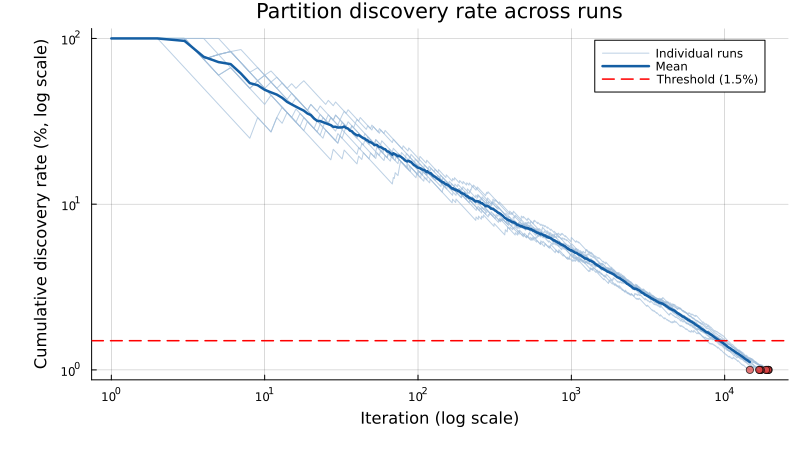

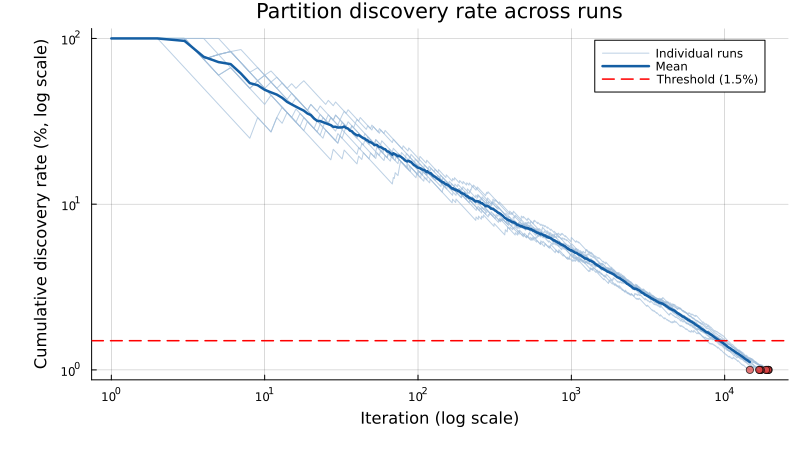

In [ ]:
p = plot_discovery_rates(all_runs;
    threshold = 0.015,
    pct       = true,           # y-axis in %, not fraction
    savepath  = "discovery_rates_logscale_school.png",
    logscale  = true
)

### Calculating the amount of overlap between runs 
This is not a symmetric chart. For each run (run a), we compare it with all other runs. In each comparision, we are calculating the number of comparisons in run a that are also in the run we are comparing it against. This gives a measure and idea of how much

In [ ]:


"""
    compute_run_overlap(all_runs)

For each ordered pair (i, j), computes:
    |unique_ptns(i) ∩ unique_ptns(j)| / |unique_ptns(i)|

i.e. the fraction of run i's partitions that also appear in run j.
Rows and columns are sorted by ascending number of unique partitions.

Returns (overlap_matrix, sorted_run_ids, sorted_sizes)
"""
function compute_run_overlap(all_runs)
    K = length(all_runs)

    # Sort runs by number of unique partitions (ascending)
    sizes          = [length(r.result.unique_ptns) for r in all_runs]
    sorted_indices = sortperm(sizes)
    sorted_sizes   = sizes[sorted_indices]
    sorted_run_ids = [all_runs[k].run_id for k in sorted_indices]

    # Convert to Sets using the sorted order
    ptn_sets = [Set(all_runs[k].result.unique_ptns) for k in sorted_indices]

    overlap_matrix = zeros(Float64, K, K)

    for i in 1:K
        for j in 1:K
            if i == j
                overlap_matrix[i, j] = 1.0
            else
                n_shared = length(intersect(ptn_sets[i], ptn_sets[j]))
                overlap_matrix[i, j] = n_shared / sorted_sizes[i]
            end
        end
    end

    return overlap_matrix, sorted_run_ids, sorted_sizes
end


"""
    plot_run_overlap(overlap_matrix, sorted_run_ids, sorted_sizes; savepath=nothing)

Plots the asymmetric overlap matrix as an annotated heatmap.
Axes are labeled with run ID and size so the ordering is clear.
"""
function plot_run_overlap(overlap_matrix, sorted_run_ids, sorted_sizes; savepath="run_overlap.png")
    K = size(overlap_matrix, 1)

    # Axis tick labels: "Run X (n=Y)"
    tick_labels = ["Run $(sorted_run_ids[k])\n(n=$(sorted_sizes[k]))" for k in 1:K]

    p = heatmap(
        overlap_matrix;
        color         = :blues,
        clim          = (0.0, 1.0),
        xlabel        = "Run j  (partitions to match against)",
        ylabel        = "Run i  (fraction of i found in j)",
        title         = "Partition overlap: |i ∩ j| / |i|",
        xticks        = (1:K, tick_labels),
        yticks        = (1:K, tick_labels),
        xrotation     = 45,
        size          = (150 + 80*K, 100 + 80*K),
        left_margin   = 80Plots.px,
        bottom_margin = 80Plots.px,
        aspect_ratio  = :equal
    )

    # Annotate each cell
    for i in 1:K, j in 1:K
        val = overlap_matrix[i, j]
        # use white text on dark cells, dark text on light cells
        txt_color = val > 0.6 ? :white : :black
        annotate!(p, j, i, text("$(round(val, digits=2))", 7, txt_color))
    end

    isnothing(savepath) || savefig(p, savepath)
    display(p)
    return p
end

plot_run_overlap

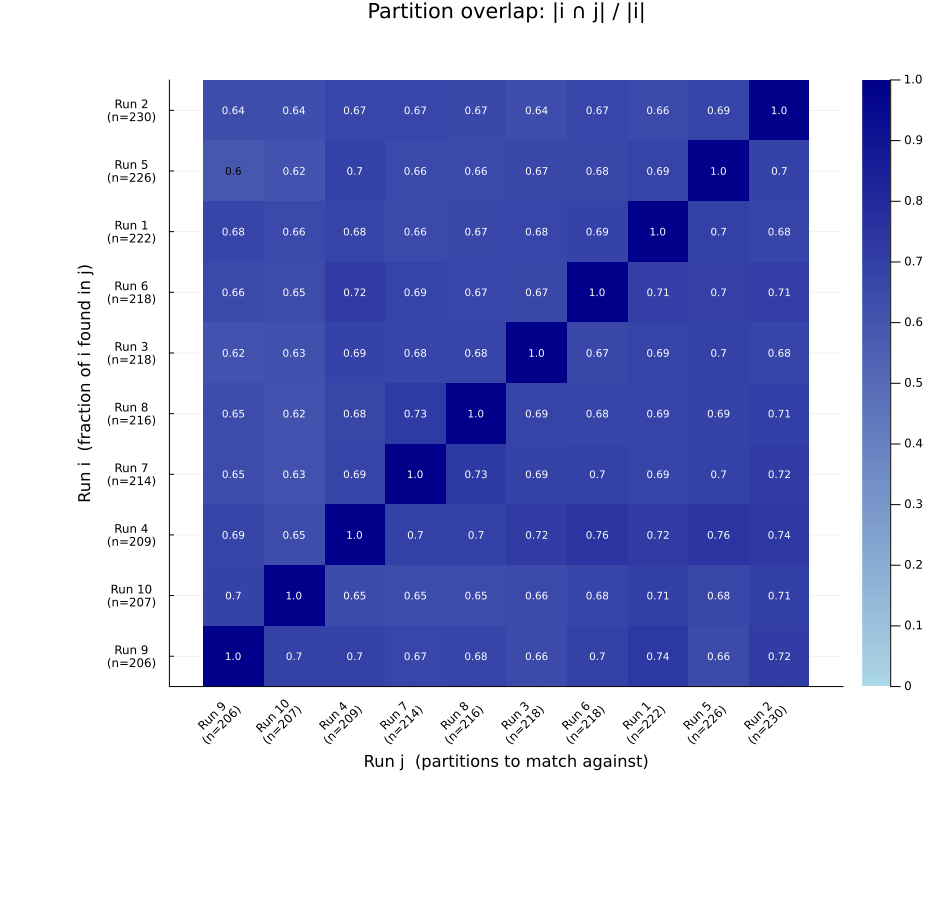

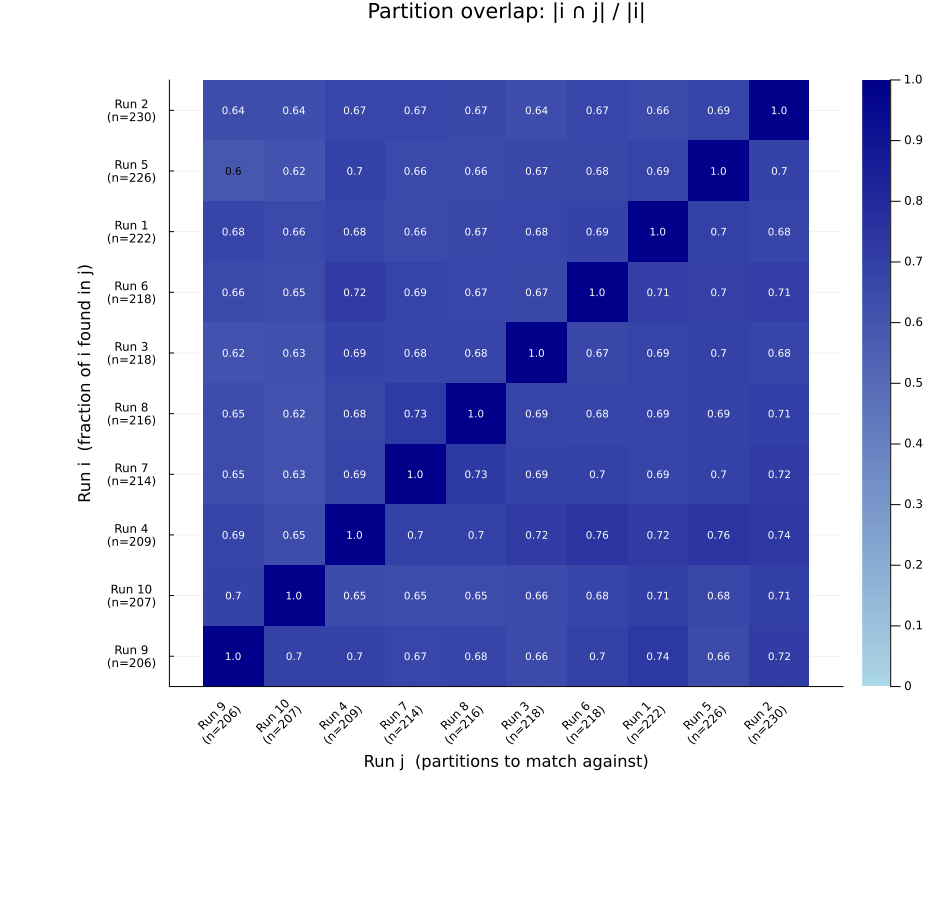

In [ ]:
overlap_matrix, sorted_run_ids, sorted_sizes = compute_run_overlap(all_runs)
p = plot_run_overlap(overlap_matrix, sorted_run_ids, sorted_sizes; savepath="run_overlap_school.png")

## FINAL DISCOVERY FUNCTION
This function takes the experiments from above and applies the actual discovery function. That is, it takes a given discovery rate and runs the discovery phase until that threshold is met. Once it has been met, the discovery phase ends and the unique paritions are returned. 

In [ ]:
function aon_alternating_discovery(
        H_lcc, e2n, n2e, weights, d, n, kmax, edge_lengths;
        max_iters        = 100000,
        randflag         = true,
        verbose          = false,
        maxits           = 100, # For the louvain search
        disc_threshold   = .20,
        print_updates    = false
    )

    # ── Initialize partition and parameters ──────────────────────────
    Z           = CliqueExpansionModularity(H_lcc)
    β, γ, omega = learn_omega_aon(e2n, weights, Z, kmax, d, n)

    # ── Storage ──────────────────────────────────────────────────────
    unique_ptns  = Vector{Int}[]
    past_results = Dict{Int, Tuple{Float64, Vector{Int}, Vector{Float64}, Vector{Float64}}}()

    # beta_history[i, k] = β_k used in iteration i  (pre-allocated, trimmed at end)
    # gamma_history[i, k] = γ_k used in iteration i
    beta_history  = zeros(Float64, max_iters, kmax)
    gamma_history = zeros(Float64, max_iters, kmax)
    all_z_history = Vector{Int}[]

    actual_iters       = 0

    # keep track of the learning rate - start at 1
    discovery_rate = 1

    println("Starting alternating AON optimization...")
    println("Initial β = $β")
    println("Initial γ = $γ")

    for i in 1:max_iters
        actual_iters = i
        # println("── Iteration $i ──────────────────────────────")

        # Record β and γ BEFORE the Louvain step — these are the parameters
        # that drive partition search in this iteration
        beta_history[i, :]  = β
        gamma_history[i, :] = γ

        # ── Partition search: run AON Louvain ─────────────────────────
        AllClusterings = AON_Louvain(
            n2e, e2n, weights, d, edge_lengths, β, γ, kmax,
            randflag, maxits, verbose
        )
        Z = AllClusterings[:, end]
        Z = reorder_Z(Z, length(unique(Z)))
        push!(all_z_history, Z)
        nk = length(unique(Z))

        # Track whether this partition has been seen before
        if Z in unique_ptns
            if print_updates
                println("  [FLAG] Partition already seen before")
            end
        else
            push!(unique_ptns, Z)
        end

        # Evaluate modularity under the current omega (from the iteration that led to this partition)
        modu, likeli = modularity_aon(H_lcc, Z, omega; likelihood=true)
        past_results[i] = (modu, copy(Z), copy(β), copy(γ))


        # ── SECOND CHECK ─────────────────────────────────────────────
        # Re-score all previously seen unique partitions under the newly
        # updated omega. Catches cases where an earlier partition is
        # actually better under the current parameter estimates.
        second_best_modu = modu
        second_best_Z    = Z
        second_best_idx  = -1

        for (j, past_Z) in enumerate(unique_ptns)
            past_modu = modularity_aon(H_lcc, past_Z, omega; likelihood=false)
            if past_modu > second_best_modu
                second_best_modu = past_modu
                second_best_Z    = past_Z
                second_best_idx  = j
            end
        end

        if second_best_idx != -1 
            if print_updates
                println("  >>> partition #$second_best_idx " *
                        "scores $second_best_modu > partition best $best_modularity <<<")
            end
            Z                 = second_best_Z   # next iteration starts from the winner
        end

        # ── update the learning rate ─────────────────────────────────

        # number of unique partitions divided by the number of iterations 
        discovery_rate = length(unique_ptns) ./ (i)

        if discovery_rate <= disc_threshold
            println("discovery rate has reached $(discovery_rate) - Ending exploration phase.")
            break
        end
        

        # --- otherwise, continue on with the estimation phase 
        
        # skip the re-estimation if Z is length one
        if length(unique(Z)) == 1
            if print_updates
                println("Single cluster partition — skipping parameter update")
            end
        else
            β, γ, omega = learn_omega_aon(e2n, weights, Z, kmax, d, n)
        end

        nk = length(unique(Z))

        if print_updates
            println("  modularity=$modu  loglik=$likeli  k=$nk")
            println("  β = $β")
            println("  γ = $γ")
        end

        # Can uncomment to look at how the beta and gamma values are changing over the iterations (used for debugging)

        # for k = 2:kmax
        #     β[k] = log(omega[1,k]) - log(omega[2,k])
        #     γ[k] = (omega[1,k] - omega[2,k]) / β[k]
        #     println("k=$k: ω₁=$(omega[1,k])  ω₀=$(omega[2,k])  β=$(β[k])  γ=$(γ[k])")
        # end

    end

    # Trim history matrices to the number of iterations actually run
    beta_history  = beta_history[1:actual_iters, :]
    gamma_history = gamma_history[1:actual_iters, :]

    println("\n─── Alternating optimization complete ───")
    println("Unique partitions found : $(length(unique_ptns))")

    return (
        unique_ptns   = unique_ptns,
        n_iters       = actual_iters,
        all_z_history = all_z_history,
        disc_rate     = discovery_rate
    )
end

aon_alternating_discovery (generic function with 1 method)

In [ ]:
# run the aon_alternating_discovery function
results = aon_alternating_discovery(
        H_lcc, e2n, n2e, weights, d, n, kmax, edge_lengths;
        max_iters        = 100000,
        randflag         = true,
        verbose          = false,
        maxits           = 100,
        disc_threshold   = .3,
        print_updates    = false)

unique_ptns   = results.unique_ptns
n_iters       = results.n_iters
all_z_history = results.all_z_history
disc_rate     = results.disc_rate


Starting alternating AON optimization...
Initial β = [0.0, 1.9894731298709, 4.111340796991678, 6.178281464587823, 7.5382722748532345]
Initial γ = [0.0, 0.00010790849845209646, 4.187848307728799e-8, 2.1353678785903954e-11, 1.0938283209973572e-14]
discovery rate has reached 0.3 - Ending exploration phase.

─── Alternating optimization complete ───
Unique partitions found : 1965
Best modularity         : -Inf
Best β                  : [0.0, 1.9894731298709, 4.111340796991678, 6.178281464587823, 7.5382722748532345]
Best γ                  : [0.0, 0.00010790849845209646, 4.187848307728799e-8, 2.1353678785903954e-11, 1.0938283209973572e-14]


0.3

## Mapping phase: build the finite-deterministic map of the unique partitions
This phase takes the unique partitions and re-evaluates the modularity scores of all other partitions against each partition's parameters. Again, this is a simple opportunity to increase efficiency by saving the modularity scores under different parameter conditions earlier on. 

It then creates the finite map.

In [ ]:
"""

Arguments:
  H           : the hypergraph
  Z_unique    : Vector of unique partition vectors (each is a Vector{Int})


Returns:
  map_target  : Vector{Int}, where map_target[i] = j means partition i maps to j
  Q_matrix    : N×N matrix of scores (Q_matrix[i,j] = score of z_j under params of z_i)
  beta_list   : Vector of beta vectors, one per partition
  gamma_list  : Vector of gamma vectors, one per partition
"""
function build_partition_map(H, Z_unique, e2n, weights, kmax, d, n)
    N = length(Z_unique)
    Q_matrix   = zeros(Float64, N, N)
    beta_list  = Vector{Any}(undef, N)
    gamma_list = Vector{Any}(undef, N)
    map_target = zeros(Int, N)

    for i in 1:N
        # learn parameters from partition i
        β_i, γ_i, omega_i = learn_omega_aon(e2n, weights, Z_unique[i], kmax, d, n)
        beta_list[i]  = β_i
        gamma_list[i] = γ_i

        # score all of the partitions under the current parameters
        for j in 1:N
            Q_matrix[i, j] = modularity_aon(H, Z_unique[j], omega_i; likelihood=false)
        end

        # Check which partition is the max -> add this one to the map
        map_target[i] = argmax(Q_matrix[i, :])
    end

    return map_target, Q_matrix, beta_list, gamma_list
end

"""
Find fixed points and cycles in the map.
"""
function analyze_map(map_target::Vector{Int})
    N = length(map_target)
    
    # Fixed points: i maps to itself
    fixed_points = findall(i -> map_target[i] == i, 1:N)
    
    # Trace all chains until cycle or fixed point
    # Returns: for each i, the eventual attractor (fixed point or cycle rep)
    attractor = zeros(Int, N)
    cycle_membership = Dict{Int, Vector{Int}}()  # cycle_rep -> [members]
    
    for start in 1:N
        # Follow the chain
        visited = Int[]
        visited_set = Set{Int}()
        cur = start
        while !(cur in visited_set)
            push!(visited, cur)
            push!(visited_set, cur)
            cur = map_target[cur]
        end
        # cur is the first repeated node — beginning of cycle
        cycle_start_idx = findfirst(==(cur), visited)
        cycle = visited[cycle_start_idx:end]
        cycle_rep = minimum(cycle)  # canonical representative
        
        # Register cycle
        if !haskey(cycle_membership, cycle_rep)
            cycle_membership[cycle_rep] = cycle
        end
        
        attractor[start] = cycle_rep
    end
    
    # Classify cycles
    cycles = unique(values(cycle_membership))
    fixed_pts  = [c[1] for c in cycles if length(c) == 1]
    true_cycles = [c for c in cycles if length(c) > 1]
    
    return (
        fixed_points = fixed_pts,
        cycles = true_cycles,
        attractor = attractor,
        cycle_membership = cycle_membership
    )
end


analyze_map

In [ ]:
# Example usage: build the partition map and anlyze it (next cell)
map_target, Q_matrix, beta_list, gamma_list = build_partition_map(H_lcc, 
    unique_ptns, e2n, weights, kmax, d, n)


([1849, 1849, 265, 265, 265, 1849, 1849, 1849, 1849, 265  …  1849, 265, 1849, 1849, 1849, 265, 265, 1849, 1849, 265], [-2528.4478620352684 -2488.291593878281 … -2552.005691338992 -2669.497577566334; -2572.3642416857883 -2528.124416082091 … -2600.0041266256717 -2743.276500004918; … ; -2503.091986051453 -2466.250831106048 … -2520.412701844294 -2592.9983626322287; -2479.157408775201 -2449.04287602272 … -2487.3287699277753 -2497.555393421748], Any[[0.0, 1.6967900864550707, 3.40671744993994, 4.822235955707502, 5.6206852517437085], [0.0, 1.8287534018789717, 3.547966837074334, 5.204628052943679, 6.18129228178956], [0.0, 1.831171378434302, 3.245281820026257, 4.749923967180276, 5.164416864996348], [0.0, 1.7027231274951085, 3.1221391706543464, 4.425729686261622, 5.085652896911363], [0.0, 1.7358088096155786, 3.3472863105395767, 4.531398288195515, 5.182968782806562], [0.0, 1.902076337044866, 3.6185593928679154, 5.142652309415489, 6.1527788346284815], [0.0, 1.8986532866798527, 3.626969159900508, 5.

In [ ]:
map_analysis = analyze_map(map_target)

(fixed_points = [1849], cycles = Vector{Int64}[], attractor = [1849, 1849, 1849, 1849, 1849, 1849, 1849, 1849, 1849, 1849  …  1849, 1849, 1849, 1849, 1849, 1849, 1849, 1849, 1849, 1849], cycle_membership = Dict(1849 => [1849]))

In [ ]:

"""
Export map results to CSV for analysis.
"""
function export_map_to_csv(map_target, Q_matrix, beta_list, gamma_list,
                            Z_unique, map_analysis; filename="partition_map_school.csv")
    N = length(map_target)
    df = DataFrame(
        partition_id  = 1:N,
        maps_to       = map_target,
        is_fixed_point = [map_target[i] == i for i in 1:N],
        attractor     = map_analysis.attractor,
        self_score    = [Q_matrix[i, i] for i in 1:N],
        winner_score  = [Q_matrix[i, map_target[i]] for i in 1:N],
        score_gain    = [Q_matrix[i, map_target[i]] - Q_matrix[i, i] for i in 1:N],
        n_clusters    = [length(unique(z)) for z in Z_unique],
    )
    # Optionally add beta_k for each k
    k_max = length(beta_list[1])
    for k in 1:k_max
        df[!, Symbol("beta_$k")] = [beta_list[i][k] for i in 1:N]
        df[!, Symbol("gamma_$k")] = [gamma_list[i][k] for i in 1:N]
    end
    CSV.write(filename, df)
    println("Saved map to $filename")
    return df
end

export_map_to_csv

In [ ]:
export_map_to_csv(map_target, Q_matrix, beta_list, gamma_list,
                            unique_ptns, map_analysis; filename="partition_map_school.csv")

Saved map to partition_map_new1.csv


Row,partition_id,maps_to,is_fixed_point,attractor,self_score,winner_score,score_gain,n_clusters,beta_1,gamma_1,beta_2,gamma_2,beta_3,gamma_3,beta_4,gamma_4,beta_5,gamma_5
,Int64,Int64,Bool,Int64,Float64,Float64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,1849,false,1849,-2528.45,-2478.83,49.6192,5,0.0,0.0,1.69679,8.80371e-5,3.40672,2.32373e-8,4.82224,7.2989e-12,5.62069,2.26434e-15
2,2,1849,false,1849,-2528.12,-2516.26,11.8635,5,0.0,0.0,1.82875,8.44843e-5,3.54797,2.1951e-8,5.20463,7.14375e-12,6.18129,2.4632e-15
3,3,265,false,1849,-2513.19,-2475.19,37.9957,5,0.0,0.0,1.83117,7.25527e-5,3.24528,1.52822e-8,4.74992,3.98271e-12,5.16442,1.14477e-15
4,4,265,false,1849,-2511.77,-2475.54,36.228,4,0.0,0.0,1.70272,7.16289e-5,3.12214,1.45117e-8,4.42573,3.66104e-12,5.08565,1.00984e-15
5,5,265,false,1849,-2513.49,-2475.8,37.6846,5,0.0,0.0,1.73581,7.94851e-5,3.34729,1.72596e-8,4.5314,4.39121e-12,5.18297,1.16181e-15
6,6,1849,false,1849,-2528.84,-2512.87,15.9633,5,0.0,0.0,1.90208,8.4203e-5,3.61856,2.207e-8,5.14265,7.27417e-12,6.15278,2.5642e-15
7,7,1849,false,1849,-2530.24,-2517.18,13.0562,5,0.0,0.0,1.89865,8.495e-5,3.62697,2.26811e-8,5.16585,7.6495e-12,6.2432,2.76524e-15
8,8,1849,false,1849,-2526.7,-2506.78,19.9161,5,0.0,0.0,1.92196,8.28996e-5,3.4574,2.10798e-8,4.958,6.69771e-12,6.01493,2.28658e-15
9,9,1849,false,1849,-2526.72,-2506.86,19.8675,5,0.0,0.0,1.91436,8.30898e-5,3.4937,2.11627e-8,5.0032,6.72863e-12,6.01674,2.29002e-15


In [ ]:
# Reload the data from the CSV to track the partition mapping

# ============================================================
# RELOAD partition_map.csv INTO JULIA
# ============================================================

df_map = CSV.read("partition_map_school.csv", DataFrame)

# ── Reconstruct the core map variables ───────────────────────────────────────

map_target   = df_map.maps_to           # Vector{Int}: i -> j
is_fixed_pt  = df_map.is_fixed_point    # BitVector
attractor    = df_map.attractor         # Vector{Int}: basin each partition drains to
n_clusters   = df_map.n_clusters        # Vector{Int}: K per partition
self_score   = df_map.self_score        # Vector{Float64}: Q(z_i, β_i)
winner_score = df_map.winner_score      # Vector{Float64}: Q(z_j, β_i) where j = map_target[i]
score_gain   = df_map.score_gain        # Vector{Float64}: winner_score - self_score

# ── Reconstruct beta and gamma profiles ──────────────────────────────────────
# Identify which columns are beta/gamma by name pattern

beta_cols  = [col for col in names(df_map) if startswith(string(col), "beta_")]
gamma_cols = [col for col in names(df_map) if startswith(string(col), "gamma_")]

# beta_matrix[i, k] = β_k for partition i  (n_partitions × k_max)
beta_matrix  = Matrix(df_map[:, beta_cols])
gamma_matrix = Matrix(df_map[:, gamma_cols])

N    = nrow(df_map)
kmax = length(beta_cols)   

println("Loaded $N partitions, kmax=$kmax")
println("Fixed points: $(sum(is_fixed_pt))")
println("Unique attractors: $(length(unique(attractor)))")

Loaded 1965 partitions, kmax=5
Fixed points: 1
Unique attractors: 1


### Export in a map format to be read in Python script

In [ ]:


# 1. Edge list for the directed map graph
df_edges = DataFrame(
    src           = df_map.partition_id,
    dst           = map_target,
    is_self_loop  = is_fixed_pt,
    score_gain    = score_gain
)
CSV.write("map_edges_school.csv", df_edges)

# 2. Node attributes
df_nodes = DataFrame(
    partition_id   = df_map.partition_id,
    n_clusters     = n_clusters,
    self_score     = self_score,
    is_fixed_point = is_fixed_pt,
    attractor      = attractor
)
CSV.write("map_nodes_school.csv", df_nodes)

println("Exported map_edges1.csv and map_nodes1.csv for Python")

Exported map_edges1.csv and map_nodes1.csv for Python


## These cells can be used to re-load past run data that has been saved ot CSVs

In [ ]:
struct RunData
    run_id      :: Int
    stop_iter   :: Int
    cum_counts  :: Vector{Int}
    cum_rates   :: Vector{Float64}
    unique_ptns :: Vector{Vector{Int}}
    all_ptns    :: Vector{Vector{Int}}
end

In [ ]:
function load_experiment_runs(dir::String; n_runs::Int = 10)
    all_runs = RunData[]
    for k in 1:n_runs
        rate_path = joinpath(dir, "run_$(k)_rates.csv")
        uptn_path = joinpath(dir, "run_$(k)_unique_ptns.csv")
        aptn_path = joinpath(dir, "run_$(k)_all_ptns.csv")

        if !isfile(rate_path)
            @warn "Missing $rate_path — skipping run $k"
            continue
        end

        rate_df = CSV.read(rate_path, DataFrame)
        n_iters = nrow(rate_df)

        unique_ptns = Vector{Vector{Int}}()
        if isfile(uptn_path)
            udf = CSV.read(uptn_path, DataFrame)
            node_cols = [c for c in names(udf) if startswith(string(c), "node_")]
            for row in eachrow(udf)
                push!(unique_ptns, Vector{Int}(row[node_cols]))
            end
        end

        all_ptns = Vector{Vector{Int}}()
        if isfile(aptn_path)
            adf = CSV.read(aptn_path, DataFrame)
            node_cols = [c for c in names(adf) if startswith(string(c), "node_")]
            for row in eachrow(adf)
                push!(all_ptns, Vector{Int}(row[node_cols]))
            end
        end

        push!(all_runs, RunData(
            k,
            n_iters,
            Vector{Int}(rate_df.cum_unique),
            Vector{Float64}(rate_df.cum_rate),
            unique_ptns,
            all_ptns
        ))
    end
    println("Loaded $(length(all_runs)) runs from $dir")
    return all_runs
end

load_experiment_runs (generic function with 1 method)

In [ ]:
all_runs = load_experiment_runs("experiment_results"; n_runs=9)

Loaded 9 runs from experiment_results


9-element Vector{RunData}:
 RunData(1, 30000, [1, 2, 3, 3, 3, 4, 4, 4, 4, 4  …  222, 222, 222, 222, 222, 222, 222, 222, 222, 222], [1.0, 1.0, 1.0, 0.75, 0.6, 0.6666666666666666, 0.5714285714285714, 0.5, 0.4444444444444444, 0.4  …  0.00740222066619986, 0.007401973859695919, 0.007401727069649585, 0.007401480296059212, 0.007401233538923154, 0.007400986798239765, 0.007400740074007401, 0.007400493366224415, 0.007400246674889163, 0.0074], [[1, 1, 1, 1, 1, 2, 2, 2, 3, 3  …  2, 3, 2, 2, 2, 2, 4, 1, 3, 4], [1, 1, 1, 1, 1, 2, 2, 2, 3, 3  …  2, 3, 2, 2, 2, 2, 1, 1, 3, 1], [1, 1, 1, 1, 1, 2, 2, 2, 3, 3  …  2, 3, 2, 2, 2, 2, 3, 1, 3, 3], [1, 1, 1, 1, 1, 1, 1, 1, 2, 2  …  1, 2, 3, 3, 1, 3, 2, 1, 2, 2], [1, 1, 1, 1, 1, 2, 2, 2, 3, 3  …  2, 1, 2, 2, 2, 2, 4, 1, 1, 4], [1, 1, 1, 1, 1, 2, 2, 2, 2, 2  …  2, 2, 3, 3, 2, 3, 4, 1, 2, 4], [1, 1, 1, 1, 1, 2, 2, 2, 2, 2  …  2, 2, 3, 3, 2, 3, 4, 1, 2, 4], [1, 1, 1, 1, 1, 2, 2, 2, 3, 3  …  2, 2, 3, 3, 2, 3, 4, 1, 2, 4], [1, 1, 1, 1, 1, 2, 2, 2, 3, 3  …  2, 4, 3,

In [ ]:
# This is a helper function to find the number of unique partitions found at a given threshold of a discovery rate
# It can be used if pulling from a run that did not stop at a specific discovery rate threshold.
function unique_ptns_at_threshold(all_z_history::Vector{Vector{Int}};
                                   threshold::Float64 = 0.2)
    unique_ptns = Vector{Vector{Int}}()

    for (t, Z) in enumerate(all_z_history)
        if !(Z in unique_ptns)
            push!(unique_ptns, Z)
        end

        rate = length(unique_ptns) / t
        if rate <= threshold
            println("Threshold $threshold reached at iteration $t " *
                    "($(length(unique_ptns)) unique partitions)")
            return unique_ptns
        end
    end

    @warn "Threshold $threshold never reached — returning all $(length(unique_ptns)) unique partitions"
    return unique_ptns
end

unique_ptns_at_threshold (generic function with 1 method)

Example usage: building the maps for all of the runs

In [ ]:
maps_matrix = []
unique_ptns_list = []

for i in 1:9

    df_map = CSV.read("school_experiment_results/partition_map_$(i).csv", DataFrame)
    map_target   = df_map.maps_to           # Vector{Int}: i -> j


    # get the unique partitions up to the discovery rate 
    unique_ptns = unique_ptns_at_threshold(all_runs[i].all_ptns, threshold=.01)

    map_target, Q_matrix, beta_list, gamma_list = build_partition_map(H_lcc, unique_ptns, e2n, weights, kmax, d, n)
    push!(maps_matrix, map_target)
    push!(unique_ptns_list, unique_ptns)

    # analyze the map
    map_analysis = analyze_map(map_target)
    println(map_analysis)
end
    
    

## Notable points
This takes all of the nodes that have in-degree of at least one. These are the points that have any sort of structural relevance in the graphs and are the ones we are interested in comparing. 

In [ ]:

for i in 1:9
    map_target = maps_matrix[i]

    notable_points = unique(map_target)
    println(notable_points)
end

[124, 169]
[132, 134]
[131, 127]
[98, 165]
[143, 165]
[127, 115]
[119, 169]
[139, 147]
[110, 161, 37]


In [ ]:
# Example usage: collect all of the notable partitions across all of the runs
all_notable_partitions = Vector{Vector{Int}}()
partition_run_labels   = Int[]        # which run each partition came from
partition_local_ids    = Int[]        # the local index within that run

for i in 1:9
    map_target     = maps_matrix[i]
    notable_points = unique(map_target)
    for p in notable_points
        push!(all_notable_partitions, all_runs[i].all_ptns[p])
        push!(partition_run_labels, i)
        push!(partition_local_ids, p)
    end
end
println(length(all_notable_partitions))
    
    
    

19


In [ ]:
"""
Export map results to CSV for analysis.
"""
function export_map_to_csv(map_target, Q_matrix, beta_list, gamma_list,
                            Z_unique, map_analysis; filename="partition_map.csv")
    N = length(map_target)
    df = DataFrame(
        partition_id  = 1:N,
        maps_to       = map_target,
        is_fixed_point = [map_target[i] == i for i in 1:N],
        attractor     = map_analysis.attractor,
        self_score    = [Q_matrix[i, i] for i in 1:N],
        winner_score  = [Q_matrix[i, map_target[i]] for i in 1:N],
        score_gain    = [Q_matrix[i, map_target[i]] - Q_matrix[i, i] for i in 1:N],
        n_clusters    = [length(unique(z)) for z in Z_unique],
    )
    # Optionally add beta_k for each k
    k_max = length(beta_list[1])
    for k in 1:k_max
        df[!, Symbol("beta_$k")] = [beta_list[i][k] for i in 1:N]
        df[!, Symbol("gamma_$k")] = [gamma_list[i][k] for i in 1:N]
    end
    CSV.write(filename, df)
    println("Saved map to $filename")
    return df
end

export_map_to_csv

In [ ]:
for i in 1:9
    map_target = maps_matrix[i]
    Q_matrix = Q_matrices[i]
    beta_list = beta_lists[i]
    gamma_list = gamma_lists[i]
    unique_ptns = unique_ptns_list[i]

    map_analysis = analyze_map(map_target)

    export_map_to_csv(map_target, Q_matrix, beta_list, gamma_list,
                            unique_ptns, map_analysis; filename="school_experiment_results/partition_map_$(i).csv")
end

Saved map to school_experiment_results/partition_map_1.csv
Saved map to school_experiment_results/partition_map_2.csv
Saved map to school_experiment_results/partition_map_3.csv
Saved map to school_experiment_results/partition_map_4.csv
Saved map to school_experiment_results/partition_map_5.csv
Saved map to school_experiment_results/partition_map_6.csv
Saved map to school_experiment_results/partition_map_7.csv
Saved map to school_experiment_results/partition_map_8.csv
Saved map to school_experiment_results/partition_map_9.csv


## Export the partition maps to CSVs in a way that they can be used in a graphing python script

In [ ]:
# ============================================================
# EXPORT FOR PYTHON NETWORKX VISUALIZATION
# ============================================================


for i in 1:9
    df_map = CSV.read("school_experiment_results/partition_map_$(i).csv", DataFrame)

    map_target   = df_map.maps_to           # Vector{Int}: i -> j
    is_fixed_pt  = df_map.is_fixed_point    # BitVector
    attractor    = df_map.attractor         # Vector{Int}: basin each partition drains to
    n_clusters   = df_map.n_clusters        # Vector{Int}: K per partition
    self_score   = df_map.self_score        # Vector{Float64}: Q(z_i, β_i)
    winner_score = df_map.winner_score      # Vector{Float64}: Q(z_j, β_i) where j = map_target[i]
    score_gain   = df_map.score_gain        # Vector{Float64}: winner_score - self_score
    
    # 1. Edge list for the directed map graph
    df_edges = DataFrame(
        src           = df_map.partition_id,
        dst           = map_target,
        is_self_loop  = is_fixed_pt,
        score_gain    = score_gain
    )
    CSV.write("school_experiment_results/map_edges_$(i).csv", df_edges)
    
    # 2. Node attributes
    df_nodes = DataFrame(
        partition_id   = df_map.partition_id,
        n_clusters     = n_clusters,
        self_score     = self_score,
        is_fixed_point = is_fixed_pt,
        attractor      = attractor
    )
    CSV.write("school_experiment_results/map_nodes_$(i).csv", df_nodes)
    
    println("Exported run $(i)")
end

Exported run 1
Exported run 2
Exported run 3
Exported run 4
Exported run 5
Exported run 6
Exported run 7
Exported run 8
Exported run 9


## Notable point overlap
Looking at the NMI between partitions in different runs. The use case for this is to look at "notable points" i.e. nodes with in-degree of at least one and see how similar these partitions were with one another. It is used as a contrast to the relatively low overlap between the entire batch of partitions across runs.

In [ ]:
function plot_nmi_heatmap(ptns        :: Vector{Vector{Int}},
                           run_labels  :: Vector{Int};
                           title_str   :: String = "Pairwise NMI",
                           savepath    :: Union{String,Nothing} = nothing)

    N = length(ptns)
    nmi_matrix = zeros(Float64, N, N)
    for i in 1:N, j in 1:N
        nmi_matrix[i, j] = mutualInformation(ptns[i], ptns[j])
    end

    # ── Compute block boundaries ─────────────────────────────────────
    # find where run label changes to draw dividing lines
    boundaries = Float64[]
    for i in 2:N
        if run_labels[i] != run_labels[i-1]
            push!(boundaries, i - 0.5)
        end
    end

    # ── Tick labels: "R1-1", "R1-2", ... ────────────────────────────
    run_counts = Dict{Int,Int}()
    tick_labels = String[]
    for r in run_labels
        run_counts[r] = get(run_counts, r, 0) + 1
        push!(tick_labels, "R$(r)-$(run_counts[r])")
    end

    # ── Discrete color per run for the margin strip ──────────────────
    run_ids    = sort(unique(run_labels))
    run_colors = Dict(r => Colors.distinguishable_colors(length(run_ids))[i]
                      for (i, r) in enumerate(run_ids))

    p = heatmap(
        nmi_matrix;
        color         = :viridis,
        clim          = (0.0, 1.0),
        xlabel        = "Partition j",
        ylabel        = "Partition i",
        title         = title_str,
        xticks        = (1:N, tick_labels),
        yticks        = (1:N, tick_labels),
        xrotation     = 90,
        size          = (100 + 35*N, 100 + 35*N),
        left_margin   = 60Plots.px,
        bottom_margin = 80Plots.px,
        aspect_ratio  = :equal,
    )

    # ── Draw block divider lines ─────────────────────────────────────
    for b in boundaries
        vline!(p, [b]; color=:red, linewidth=2.0, label="")
        hline!(p, [b]; color=:red, linewidth=2.0, label="")
    end

    isnothing(savepath) || savefig(p, savepath)
    display(p)
    return p, nmi_matrix
end

plot_nmi_heatmap (generic function with 1 method)

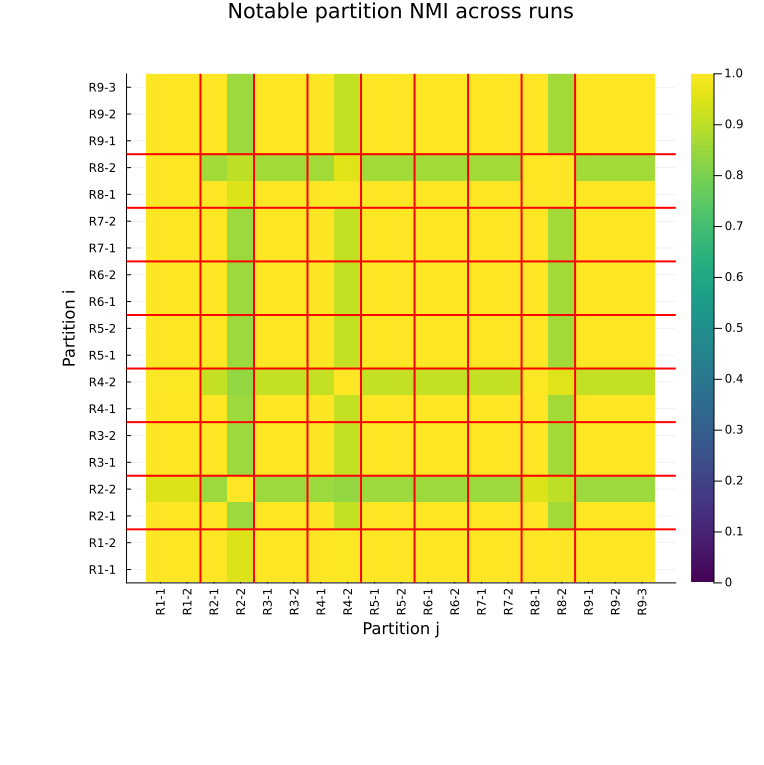

(Plot{Plots.GRBackend() n=17}, [1.3395538238670124 1.3395538238670124 … 1.0502855814677599 1.0502855814677599; 1.3395538238670124 1.3395538238670124 … 1.0502855814677599 1.0502855814677599; … ; 1.0502855814677599 1.0502855814677599 … 1.0502855814677594 1.0502855814677594; 1.0502855814677599 1.0502855814677599 … 1.0502855814677594 1.0502855814677594])

In [ ]:
p, nmi_matrix = plot_nmi_heatmap(all_notable_partitions, partition_run_labels,
                                  title_str = "Notable partition NMI across runs", savepath ="cross-runNMI_school.png")